In [1]:
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [2]:
df_temperature = pd.read_csv('DailyDelhiClimateTrain.csv', encoding='utf-8')
df_temperature.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [3]:
df_temperature.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          1462 non-null   object 
 1   meantemp      1462 non-null   float64
 2   humidity      1462 non-null   float64
 3   wind_speed    1462 non-null   float64
 4   meanpressure  1462 non-null   float64
dtypes: float64(4), object(1)
memory usage: 57.2+ KB


## Data pre-processing

In [4]:
# df_temperature.dropna(inplace=True)

## Lstm

In [5]:
import numpy as np
from keras.models import Sequential
from keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler

# Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df_temperature[['meantemp']])

# Create sequences
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

2024-07-12 14:49:19.310993: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [6]:

# Define sequence length
sequence_length = 7  # Example: Use the past 7 days to predict the next day

# Create sequences
X, y = create_sequences(scaled_data, sequence_length)

# Split the data into training and testing sets
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

from tensorflow.keras.callbacks import EarlyStopping

#Early stopping to avoid overfitting of model
early_stop=EarlyStopping(monitor='loss',mode='min', verbose=1, patience=15, restore_best_weights=True)

# Define the LSTM model
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(sequence_length, 1)))
model.add(LSTM(50))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
model.fit(X_train, y_train, epochs=100, batch_size=32, callbacks=[early_stop])

# Evaluate the model
mse = model.evaluate(X_test, y_test)
print(f"Mean Squared Error: {mse}")


Epoch 1/100
37/37 [==============================] - 7s 16ms/step - loss: 0.0542
Epoch 2/100
37/37 [==============================] - 1s 15ms/step - loss: 0.0064
Epoch 3/100
37/37 [==============================] - 1s 16ms/step - loss: 0.0048
Epoch 4/100
37/37 [==============================] - 1s 17ms/step - loss: 0.0046
Epoch 5/100
37/37 [==============================] - 1s 20ms/step - loss: 0.0048
Epoch 6/100
37/37 [==============================] - 1s 19ms/step - loss: 0.0047
Epoch 7/100
37/37 [==============================] - 1s 21ms/step - loss: 0.0046
Epoch 8/100
37/37 [==============================] - 1s 17ms/step - loss: 0.0046
Epoch 9/100
 1/37 [..............................] - ETA: 0s - loss: 0.0061

 sequence[-3:]: Extracts the last three elements of the sequence.

10/10 [==============================] - 1s 4ms/step


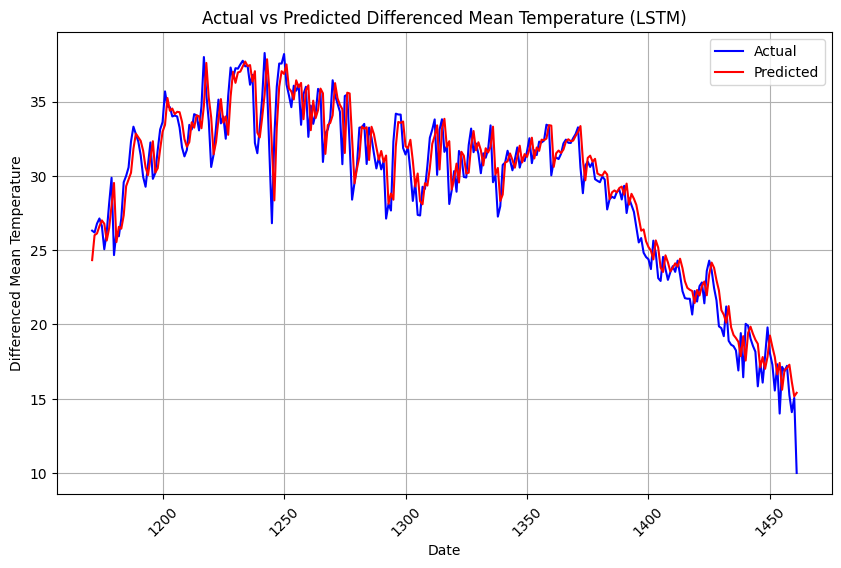

In [ ]:
# Predict on test data
y_pred_scaled = model.predict(X_test)

# Inverse transform the scaled predicted and actual values
y_pred = scaler.inverse_transform(y_pred_scaled)
y_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(df_temperature.index[-len(y_actual):], y_actual, color='blue', label='Actual')
plt.plot(df_temperature.index[-len(y_pred):], y_pred, color='red', label='Predicted')
plt.title('Actual vs Predicted Differenced Mean Temperature (LSTM)')
plt.xlabel('Date')
plt.ylabel('Differenced Mean Temperature')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


In [ ]:
mae = mean_absolute_error(y_actual, y_pred)
mse = mean_squared_error(y_actual, y_pred)
rmse = np.sqrt(mse)

print(f'MAE: {mae:.3f}')
print(f'MSE: {mse:.3f}')
print(f'RMSE: {rmse:.3f}')

MAE: 1.217
MSE: 2.648
RMSE: 1.627


******************************************

******************************************

******************************************

In [ ]:
# Train the model
model.fit(X_train, y_train, epochs=500, batch_size=32, callbacks=[early_stop])

# Evaluate the model
mse = model.evaluate(X_test, y_test)
print(f"Mean Squared Error: {mse}")

Epoch 1/500
37/37 [==============================] - 0s 7ms/step - loss: 0.0025
Epoch 2/500
37/37 [==============================] - 0s 6ms/step - loss: 0.0025
Epoch 3/500
37/37 [==============================] - 0s 6ms/step - loss: 0.0025
Epoch 4/500
37/37 [==============================] - 0s 6ms/step - loss: 0.0025
Epoch 5/500
37/37 [==============================] - 0s 6ms/step - loss: 0.0025
Epoch 6/500
37/37 [==============================] - 0s 6ms/step - loss: 0.0025
Epoch 7/500
37/37 [==============================] - 0s 6ms/step - loss: 0.0026
Epoch 8/500
37/37 [==============================] - 0s 6ms/step - loss: 0.0025
Epoch 9/500
37/37 [==============================] - 0s 6ms/step - loss: 0.0026
Epoch 10/500
37/37 [==============================] - 0s 7ms/step - loss: 0.0025
Epoch 11/500
37/37 [==============================] - 0s 6ms/step - loss: 0.0026
Epoch 12/500
37/37 [==============================] - 0s 6ms/step - loss: 0.0026
Epoch 13/500
37/37 [=================

10/10 [==============================] - 0s 3ms/step


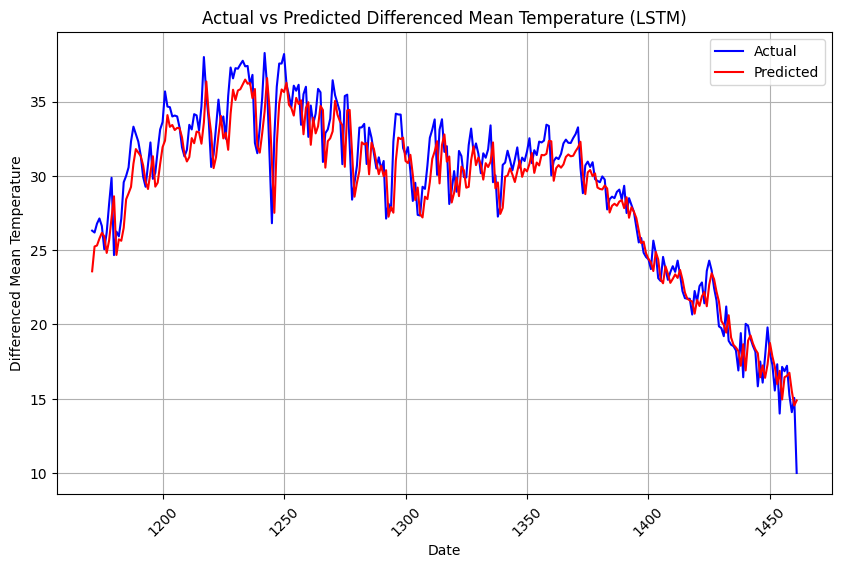

In [ ]:
# Predict on test data
y_pred_scaled = model.predict(X_test)

# Inverse transform the scaled predicted and actual values
y_pred = scaler.inverse_transform(y_pred_scaled)
y_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(df_temperature.index[-len(y_actual):], y_actual, color='blue', label='Actual')
plt.plot(df_temperature.index[-len(y_pred):], y_pred, color='red', label='Predicted')
plt.title('Actual vs Predicted Differenced Mean Temperature (LSTM)')
plt.xlabel('Date')
plt.ylabel('Differenced Mean Temperature')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [ ]:
mae = mean_absolute_error(y_actual, y_pred)
mse = mean_squared_error(y_actual, y_pred)
rmse = np.sqrt(mse)

print(f'MAE: {mae:.3f}')
print(f'MSE: {mse:.3f}')
print(f'RMSE: {rmse:.3f}')

MAE: 1.378
MSE: 2.961
RMSE: 1.721


*************************************************************

*************************************************************

*************************************************************

In [ ]:
# Train the model
model.fit(X_train, y_train, epochs=1000, batch_size=32, callbacks=[early_stop])

# Evaluate the model
mse = model.evaluate(X_test, y_test)
print(f"Mean Squared Error: {mse}")

Epoch 1/1000
37/37 [==============================] - 0s 7ms/step - loss: 0.0025
Epoch 2/1000
37/37 [==============================] - 0s 6ms/step - loss: 0.0026
Epoch 3/1000
37/37 [==============================] - 0s 6ms/step - loss: 0.0025
Epoch 4/1000
37/37 [==============================] - 0s 6ms/step - loss: 0.0025
Epoch 5/1000
37/37 [==============================] - 0s 6ms/step - loss: 0.0026
Epoch 6/1000
37/37 [==============================] - 0s 7ms/step - loss: 0.0025
Epoch 7/1000
37/37 [==============================] - 0s 6ms/step - loss: 0.0027
Epoch 8/1000
37/37 [==============================] - 0s 6ms/step - loss: 0.0025
Epoch 9/1000
37/37 [==============================] - 0s 6ms/step - loss: 0.0025
Epoch 10/1000
37/37 [==============================] - 0s 6ms/step - loss: 0.0025
Epoch 11/1000
37/37 [==============================] - 0s 6ms/step - loss: 0.0025
Epoch 12/1000
37/37 [==============================] - 0s 6ms/step - loss: 0.0024
Epoch 13/1000
37/37 [====

10/10 [==============================] - 0s 3ms/step


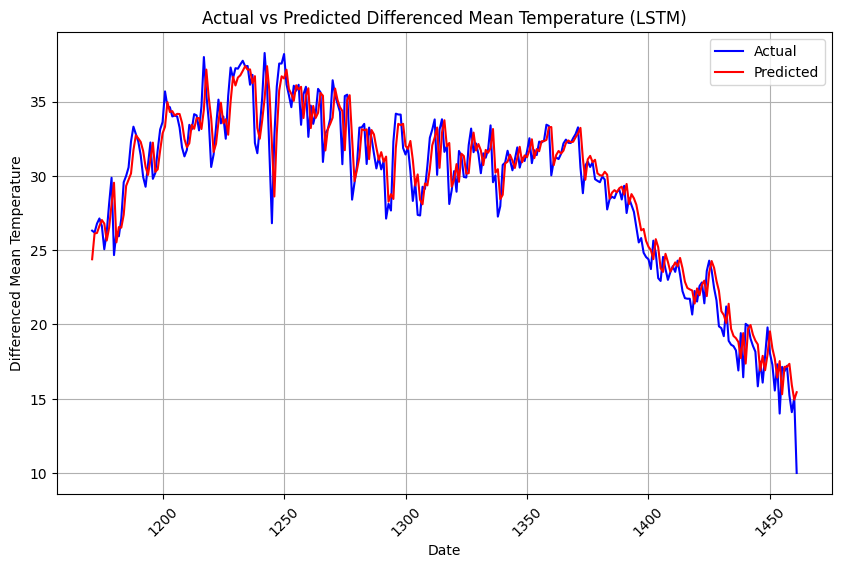

In [ ]:
# Predict on test data
y_pred_scaled = model.predict(X_test)

# Inverse transform the scaled predicted and actual values
y_pred = scaler.inverse_transform(y_pred_scaled)
y_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(df_temperature.index[-len(y_actual):], y_actual, color='blue', label='Actual')
plt.plot(df_temperature.index[-len(y_pred):], y_pred, color='red', label='Predicted')
plt.title('Actual vs Predicted Differenced Mean Temperature (LSTM)')
plt.xlabel('Date')
plt.ylabel('Differenced Mean Temperature')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [ ]:
mae = mean_absolute_error(y_actual, y_pred)
mse = mean_squared_error(y_actual, y_pred)
rmse = np.sqrt(mse)

print(f'MAE: {mae:.3f}')
print(f'MSE: {mse:.3f}')
print(f'RMSE: {rmse:.3f}')

MAE: 1.215
MSE: 2.622
RMSE: 1.619


## Forecasting

In [ ]:
import numpy as np

# Function to create sequences for forecasting
def create_forecast_sequence(data, sequence_length):
    sequence = data[-sequence_length:]  # Get the last sequence_length elements from the data
    return sequence.reshape((1, sequence_length, 1))

# Number of future steps to forecast
n_future_steps = 360  # For example, predict the next 30 days

# Prepare the initial sequence for forecasting
last_sequence = create_forecast_sequence(scaled_data, sequence_length)

# Container for storing the forecasted values
forecasted_values = []

# Iteratively forecast the future values
for _ in range(n_future_steps):
    # Predict the next value
    next_pred_scaled = model.predict(last_sequence)
    
    # Append the prediction to the forecasted values list
    forecasted_values.append(next_pred_scaled[0, 0])
    
    # Update the last_sequence by appending the predicted value and removing the first element
    # Convert the next_pred_scaled to the right shape
    next_pred_scaled_reshaped = np.array(next_pred_scaled[0, 0]).reshape((1, 1, 1))
    
    # Append the new prediction to the sequence and remove the oldest value
    last_sequence = np.append(last_sequence[:, 1:, :], next_pred_scaled_reshaped, axis=1)

# Inverse transform the forecasted values to get them back to the original scale
forecasted_values = np.array(forecasted_values).reshape(-1, 1)
forecasted_values_original_scale = scaler.inverse_transform(forecasted_values)

# Print the forecasted values
print(f"Forecasted Values (original scale): {forecasted_values_original_scale.flatten()}")


1/1 [==============================] - 0s 23ms/step
Forecasted Values (original scale): [11.980562  12.627253  13.119297  13.426993  13.630637  13.784247
 13.892442  14.0884495 14.293284  14.500488  14.702554  14.898514
 15.090059  15.279527  15.469415  15.659339  15.849013  16.038122
 16.226576  16.414433  16.60184   16.788942  16.97582   17.162529
 17.349115  17.535627  17.722115  17.908628  18.095219  18.281929
 18.468803  18.655884  18.843206  19.030802  19.218706  19.40695
 19.595554  19.784544  19.973946  20.16377   20.35404   20.544758
 20.735937  20.927586  21.119703  21.31229   21.50534   21.69885
 21.892807  22.087193  22.28199   22.477182  22.672737  22.86863
 23.064827  23.261286  23.457964  23.654821  23.851809  24.048874
 24.245958  24.442991  24.639921  24.83668   25.033182  25.229368
 25.425148  25.620447  25.815178  26.009253  26.202585  26.395079
 26.586645  26.777182  26.966597  27.154789  27.341665  27.527122
 27.711065  27.893387  28.074003  28.252806  28.429716  2

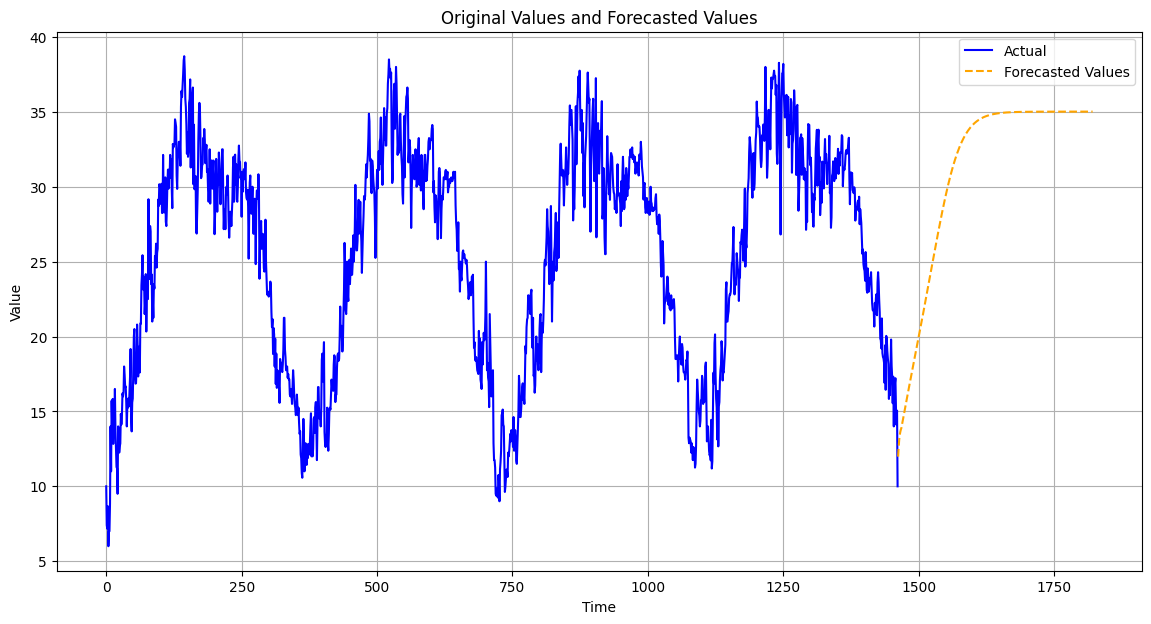

In [ ]:
y_actual = scaler.inverse_transform(scaled_data)

# Create a range of indices for the original data
original_indices = np.arange(len(y_actual))

# Create a range of indices for the forecasted data, starting from the end of the original data
forecast_indices = np.arange(len(y_actual), len(y_actual) + n_future_steps)

# Plot original values and forecasted values
plt.figure(figsize=(14, 7))
plt.plot(df_temperature.index[-len(y_actual):], y_actual, color='blue', label='Actual')
plt.plot(forecast_indices, forecasted_values_original_scale, label='Forecasted Values', linestyle='--', color='orange')
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Original Values and Forecasted Values')
plt.legend()
plt.grid(True)
plt.show()

***********************************************************

***********************************************************

***********************************************************

## Adding few more hidden layers

In [ ]:
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(sequence_length, 1)))
model.add(LSTM(50))
model.add(LSTM(50))
model.add(LSTM(50))
model.add(LSTM(50))
model.add(LSTM(50))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mean_squared_error')


In [ ]:
# Train the model
model.fit(X_train, y_train, epochs=1000, batch_size=32, callbacks=[early_stop])

# Evaluate the model
mse = model.evaluate(X_test, y_test)
print(f"Mean Squared Error: {mse}")

Epoch 1/1000
37/37 [==============================] - 13s 18ms/step - loss: 0.1909
Epoch 2/1000
37/37 [==============================] - 1s 17ms/step - loss: 0.0938
Epoch 3/1000
37/37 [==============================] - 1s 17ms/step - loss: 0.0643
Epoch 4/1000
37/37 [==============================] - 1s 17ms/step - loss: 0.0378
Epoch 5/1000
37/37 [==============================] - 1s 17ms/step - loss: 0.0286
Epoch 6/1000
37/37 [==============================] - 1s 20ms/step - loss: 0.0221
Epoch 7/1000
37/37 [==============================] - 1s 21ms/step - loss: 0.0167
Epoch 8/1000
37/37 [==============================] - 1s 17ms/step - loss: 0.0133
Epoch 9/1000
37/37 [==============================] - 1s 19ms/step - loss: 0.0118
Epoch 10/1000
37/37 [==============================] - 1s 20ms/step - loss: 0.0096
Epoch 11/1000
37/37 [==============================] - 1s 18ms/step - loss: 0.0085
Epoch 12/1000
37/37 [==============================] - 1s 19ms/step - loss: 0.0078
Epoch 13/100

10/10 [==============================] - 3s 8ms/step
Shape of y_pred_scaled: (291, 7, 1)
Length of y_actual: 291
Length of y_pred: 2037


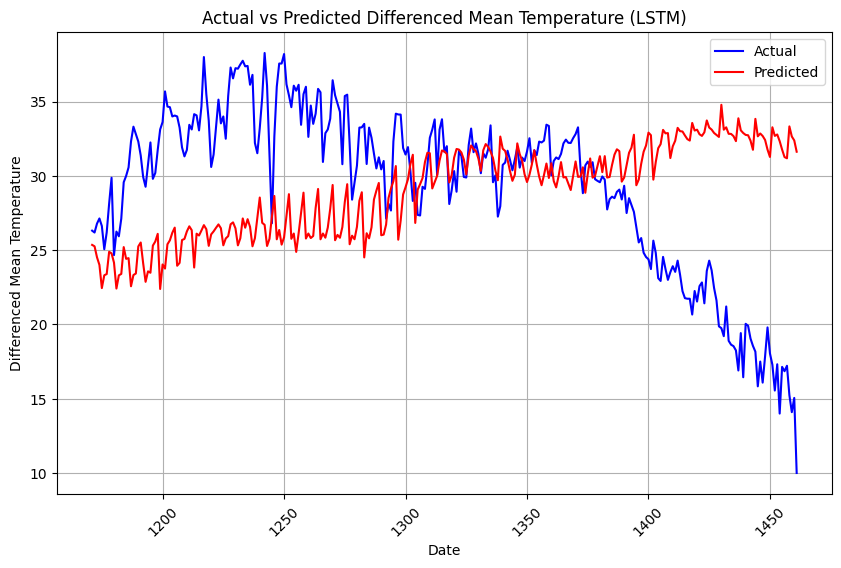

In [ ]:
# Predict on test data
y_pred_scaled = model.predict(X_test)
print(f"Shape of y_pred_scaled: {y_pred_scaled.shape}")

# Ensure y_pred_scaled is reshaped to 2D array
y_pred_scaled = y_pred_scaled.reshape(-1, 1)

# Inverse transform the scaled predicted and actual values
y_pred = scaler.inverse_transform(y_pred_scaled)
y_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

# Check the lengths of y_pred and y_actual
print(f"Length of y_actual: {len(y_actual)}")
print(f"Length of y_pred: {len(y_pred)}")

# Ensure they have the same length for plotting
min_length = min(len(y_actual), len(y_pred))
y_actual = y_actual[:min_length]
y_pred = y_pred[:min_length]

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(df_temperature.index[-len(y_actual):], y_actual, color='blue', label='Actual')
plt.plot(df_temperature.index[-len(y_actual):], y_pred, color='red', label='Predicted')  # Use len(y_actual) here
plt.title('Actual vs Predicted Differenced Mean Temperature (LSTM)')
plt.xlabel('Date')
plt.ylabel('Differenced Mean Temperature')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


In [ ]:
mae = mean_absolute_error(y_actual, y_pred)
mse = mean_squared_error(y_actual, y_pred)
rmse = np.sqrt(mse)

print(f'MAE: {mae:.3f}')
print(f'MSE: {mse:.3f}')
print(f'RMSE: {rmse:.3f}')

MAE: 6.280
MSE: 62.124
RMSE: 7.882


_________________________________________________________________

_________________________________________________________________

_________________________________________________________________

In [ ]:
import numpy as np

# Function to create sequences for forecasting
def create_forecast_sequence(data, sequence_length):
    sequence = data[-sequence_length:]  # Get the last sequence_length elements from the data
    return sequence.reshape((1, sequence_length, 1))

# Number of future steps to forecast
n_future_steps = 360  # For example, predict the next 30 days

# Prepare the initial sequence for forecasting
last_sequence = create_forecast_sequence(scaled_data, sequence_length)

# Container for storing the forecasted values
forecasted_values = []

# Iteratively forecast the future values
for _ in range(n_future_steps):
    # Predict the next value
    next_pred_scaled = model.predict(last_sequence)
    
    # Append the prediction to the forecasted values list
    forecasted_values.append(next_pred_scaled[0, 0])
    
    # Update the last_sequence by appending the predicted value and removing the first element
    # Convert the next_pred_scaled to the right shape
    next_pred_scaled_reshaped = np.array(next_pred_scaled[0, 0]).reshape((1, 1, 1))
    
    # Append the new prediction to the sequence and remove the oldest value
    last_sequence = np.append(last_sequence[:, 1:, :], next_pred_scaled_reshaped, axis=1)

# Inverse transform the forecasted values to get them back to the original scale
forecasted_values = np.array(forecasted_values).reshape(-1, 1)
forecasted_values_original_scale = scaler.inverse_transform(forecasted_values)

# Print the forecasted values
print(f"Forecasted Values (original scale): {forecasted_values_original_scale.flatten()}")

1/1 [==============================] - 0s 26ms/step
Forecasted Values (original scale): [17.803316 17.561113 17.865229 16.259539 15.37031  16.1133   12.42539
 18.355728 18.152164 18.407948 17.078062 16.364243 16.959532 14.123278
 18.824184 18.650894 18.868761 17.749578 17.1632   17.6515   15.391785
 19.225855 19.076809 19.264284 18.310469 17.820204 18.227999 16.381283
 19.573381 19.444098 19.606777 18.78559  18.369967 18.715359 17.177074
 19.876314 19.763382 19.905533 19.192612 18.836334 19.132193 17.831724
 20.142029 20.042795 20.167738 19.544514 19.236326 19.492094 18.379679
 20.376331 20.288692 20.399061 19.851072 19.58248  19.805273 18.844624
 20.583864 20.50614  20.604046 20.119827 19.884274 20.079578 19.24347
 20.768404 20.699213 20.786385 20.35671  20.14903  20.32116  19.588686
 20.933046 20.871256 20.949116 20.566454 20.382523 20.53492  19.889702
 21.080362 21.025028 21.094763 20.752897 20.589361 20.724823 20.153805
 21.212513 21.162838 21.225449 20.919193 20.773302 20.894117 2

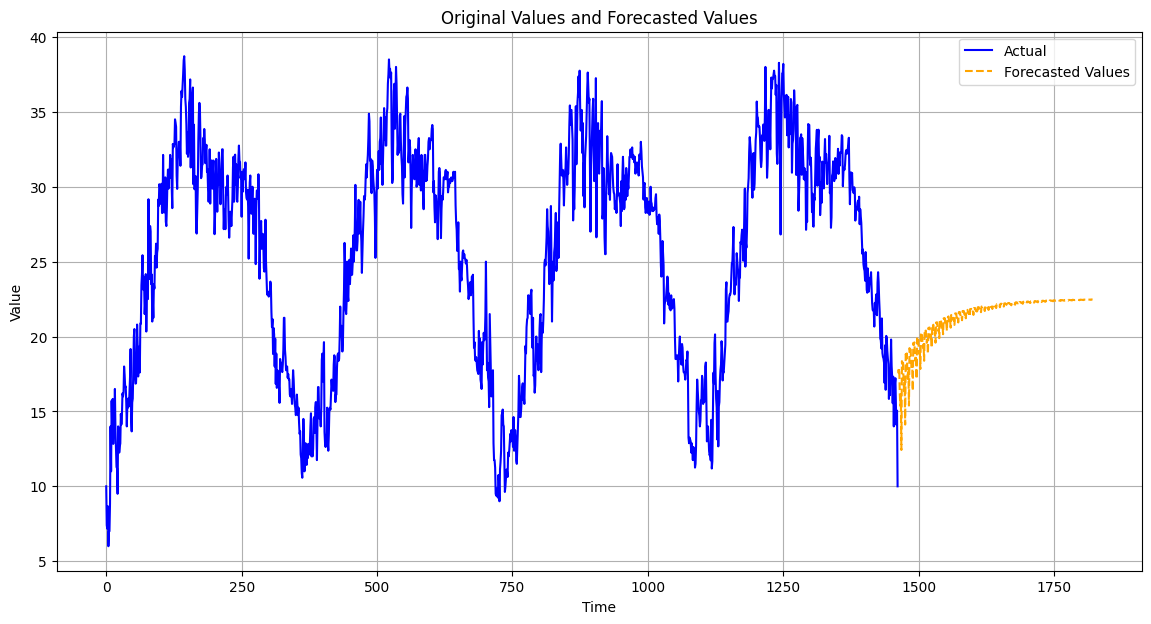

In [ ]:
y_actual = scaler.inverse_transform(scaled_data)

# Create a range of indices for the original data
original_indices = np.arange(len(y_actual))

# Create a range of indices for the forecasted data, starting from the end of the original data
forecast_indices = np.arange(len(y_actual), len(y_actual) + n_future_steps)

# Plot original values and forecasted values
plt.figure(figsize=(14, 7))
plt.plot(df_temperature.index[-len(y_actual):], y_actual, color='blue', label='Actual')
plt.plot(forecast_indices, forecasted_values_original_scale, label='Forecasted Values', linestyle='--', color='orange')
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Original Values and Forecasted Values')
plt.legend()
plt.grid(True)
plt.show()